# T70 -- PhanSST: reconstructing deep-time SST proxy sites (PETM, 56 Ma)

**Cluster J: Paleoclimate.**  *Dataset:* PhanSST -- the global Phanerozoic sea-surface-temperature proxy database (Judd, Tierney et al. 2022, *Scientific Data*, CC BY 4.0) -- 150,691 proxy measurements from 1,643 sites spanning the entire Phanerozoic (540 Ma to present).

PhanSST is a compilation, not a model: every row is a real geochemical measurement (a &delta;<sup>18</sup>O value, a Mg/Ca ratio, a TEX<sub>86</sub> index...) made on a real sample from a real drill core or outcrop, at its **present-day** location. To ask "what did the ocean look like at this site 56 million years ago" you first have to answer a plate-tectonics question -- "where *was* this site 56 million years ago" -- before you can answer the paleoclimate one. That is exactly the reconstruction step `gplately` exists to do, and it is not decorative here: the database's own paleo-latitude and -longitude were computed exactly this way by the original authors, using the plate model of Scotese & Wright (2018) in GPlates. This notebook recomputes that step from scratch, on real published data, using the same model.

## What this notebook produces

1. **&sect;2 -- The database at a glance.** Age and proxy-type distribution across the full 540 Myr record, to show why this is a genuinely large, heterogeneous compilation, not a single time-slice.
2. **&sect;3 -- Isolating one event: the Paleocene-Eocene Thermal Maximum (~56 Ma).** Subset to a single proxy type (&delta;<sup>18</sup>O carbonate) in a &plusmn;2 Myr window around the PETM, the best-sampled hyperthermal in the database.
3. **&sect;4 -- Reconstructing site positions to 56 Ma.** First with `gplately`'s default (continent-only) static polygons -- which drops most sites, because SST proxy records mostly come from open-ocean drill cores, not continental shelf -- then fixed by partitioning through the plate model's own **topological** plate boundaries instead, which cover the whole globe, ocean floor included.
4. **&sect;5 -- Mapping the reconstructed sites.** &delta;<sup>18</sup>O carbonate values at their real 56 Ma positions, on a Robinson projection with reconstructed plate boundaries for context.
5. **&sect;6 -- Does the data show the latitudinal gradient it should?** A simple, falsifiable check: proxy value vs. reconstructed paleolatitude.

## Learning objectives

- Work with a large (150k-row), multi-proxy, multi-site tabular deep-time database, and subset it to a scientifically coherent slice (one proxy type, one narrow time window).
- Understand *why* a published database's own paleo-coordinates were computed with a specific named plate model, and recompute that step independently with `gplately`/`plate_model_manager` to verify it.
- Diagnose and fix a real, common `gplately` failure mode: static continental polygons silently drop open-ocean points; resolved **topological** plate boundaries do not, because they tile the entire globe.
- Test a simple geographic hypothesis (proxy value vs. paleolatitude) against reconstructed positions, not raw present-day coordinates -- the reconstruction is not just for the map, it changes the answer.

## Prerequisites and runtime

- **Plate model**: Scotese & Wright (2018) -- not an assumption or approximation here: it is the exact model PhanSST's own authors used to compute paleo-coordinates (Judd et al. 2022, Methods: *"Paleo-latitude and -longitude of each entry was estimated using the plate model of Scotese and Wright [2018], implemented in G-Plates"*).
- **Data**: `zenodo_data/phansst_proxy_database_Judd2022/PhanSST_v001.csv` (40 MB, not bundled in git -- see `zenodo_data/README.md`). Judd, E.J., Tierney, J.E. et al. (2022), CC BY 4.0.
- **Python**: `gplately`, `pygmt`, `pygplates`, `plate_model_manager`, `xarray`, `numpy`, `pandas`.
- **Runtime**: ~30 s.


## Environment + imports

In [1]:
from pathlib import Path
import os, sys
if Path("../data").exists() and not Path("data").exists():
    os.chdir("..")

import numpy as np
import pandas as pd
import xarray as xr
import pygmt
import gplately
import pygplates
from plate_model_manager import PlateModelManager

sys.path.insert(0, str(Path("Notebooks").resolve()))
from data_check import require_data
require_data(["zenodo_data/phansst_proxy_database_Judd2022/"])

print("Environment")
print(f"  python      {sys.version.split()[0]}")
for _m in (np, pd, xr, pygmt, gplately, pygplates):
    print(f"  {_m.__name__:11s} {getattr(_m, '__version__', getattr(_m, 'version', 'n/a'))}")


Environment
  python      3.12.5
  numpy       2.3.2
  pandas      2.2.3
  xarray      2026.4.0
  pygmt       v0.18.0
  gplately    2.0.0.post19+git.2cce7bb3
  pygplates   1.0.0


## Configuration

In [2]:
# === USER CONFIGURATION =====================================================
MODEL_NAME     = "scotese_and_wright2018"  # the exact model PhanSST's own authors used
TARGET_AGE     = 56.0     # Ma -- Paleocene-Eocene Thermal Maximum (PETM)
AGE_WINDOW     = 2.0      # +/- Myr around TARGET_AGE
PROXY_TYPE     = "d18c"   # delta-18-O carbonate -- the best-sampled proxy in this window

DATA_CSV = Path("zenodo_data/phansst_proxy_database_Judd2022/PhanSST_v001.csv")

REGION = "d"
PROJ   = "N16c"

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)


## 1. Load PhanSST

In [3]:
phansst = pd.read_csv(DATA_CSV, low_memory=False)
print(f"  {len(phansst):,} rows, {phansst['SiteName'].nunique():,} unique site names, "
      f"{phansst['LeadAuthor'].nunique():,} source studies")
print(f"  age range: {phansst['Age'].min():.1f}-{phansst['Age'].max():.1f} Ma")
print(f"  proxy types: {phansst['ProxyType'].value_counts().to_dict()}")


  150,691 rows, 1,241 unique site names, 405 source studies
  age range: -0.0-522.3 Ma
  proxy types: {'d18c': 81162, 'uk': 35360, 'tex': 14091, 'mg': 13249, 'd18p': 6358, 'd18a': 471}


## 2. The database at a glance

Age distribution (all proxy types pooled) and proxy-type composition across the full 540 Myr record -- context for why the &plusmn;2 Myr PETM window used from &sect;3 onward is a deliberately narrow slice of a much larger resource, not the whole database.

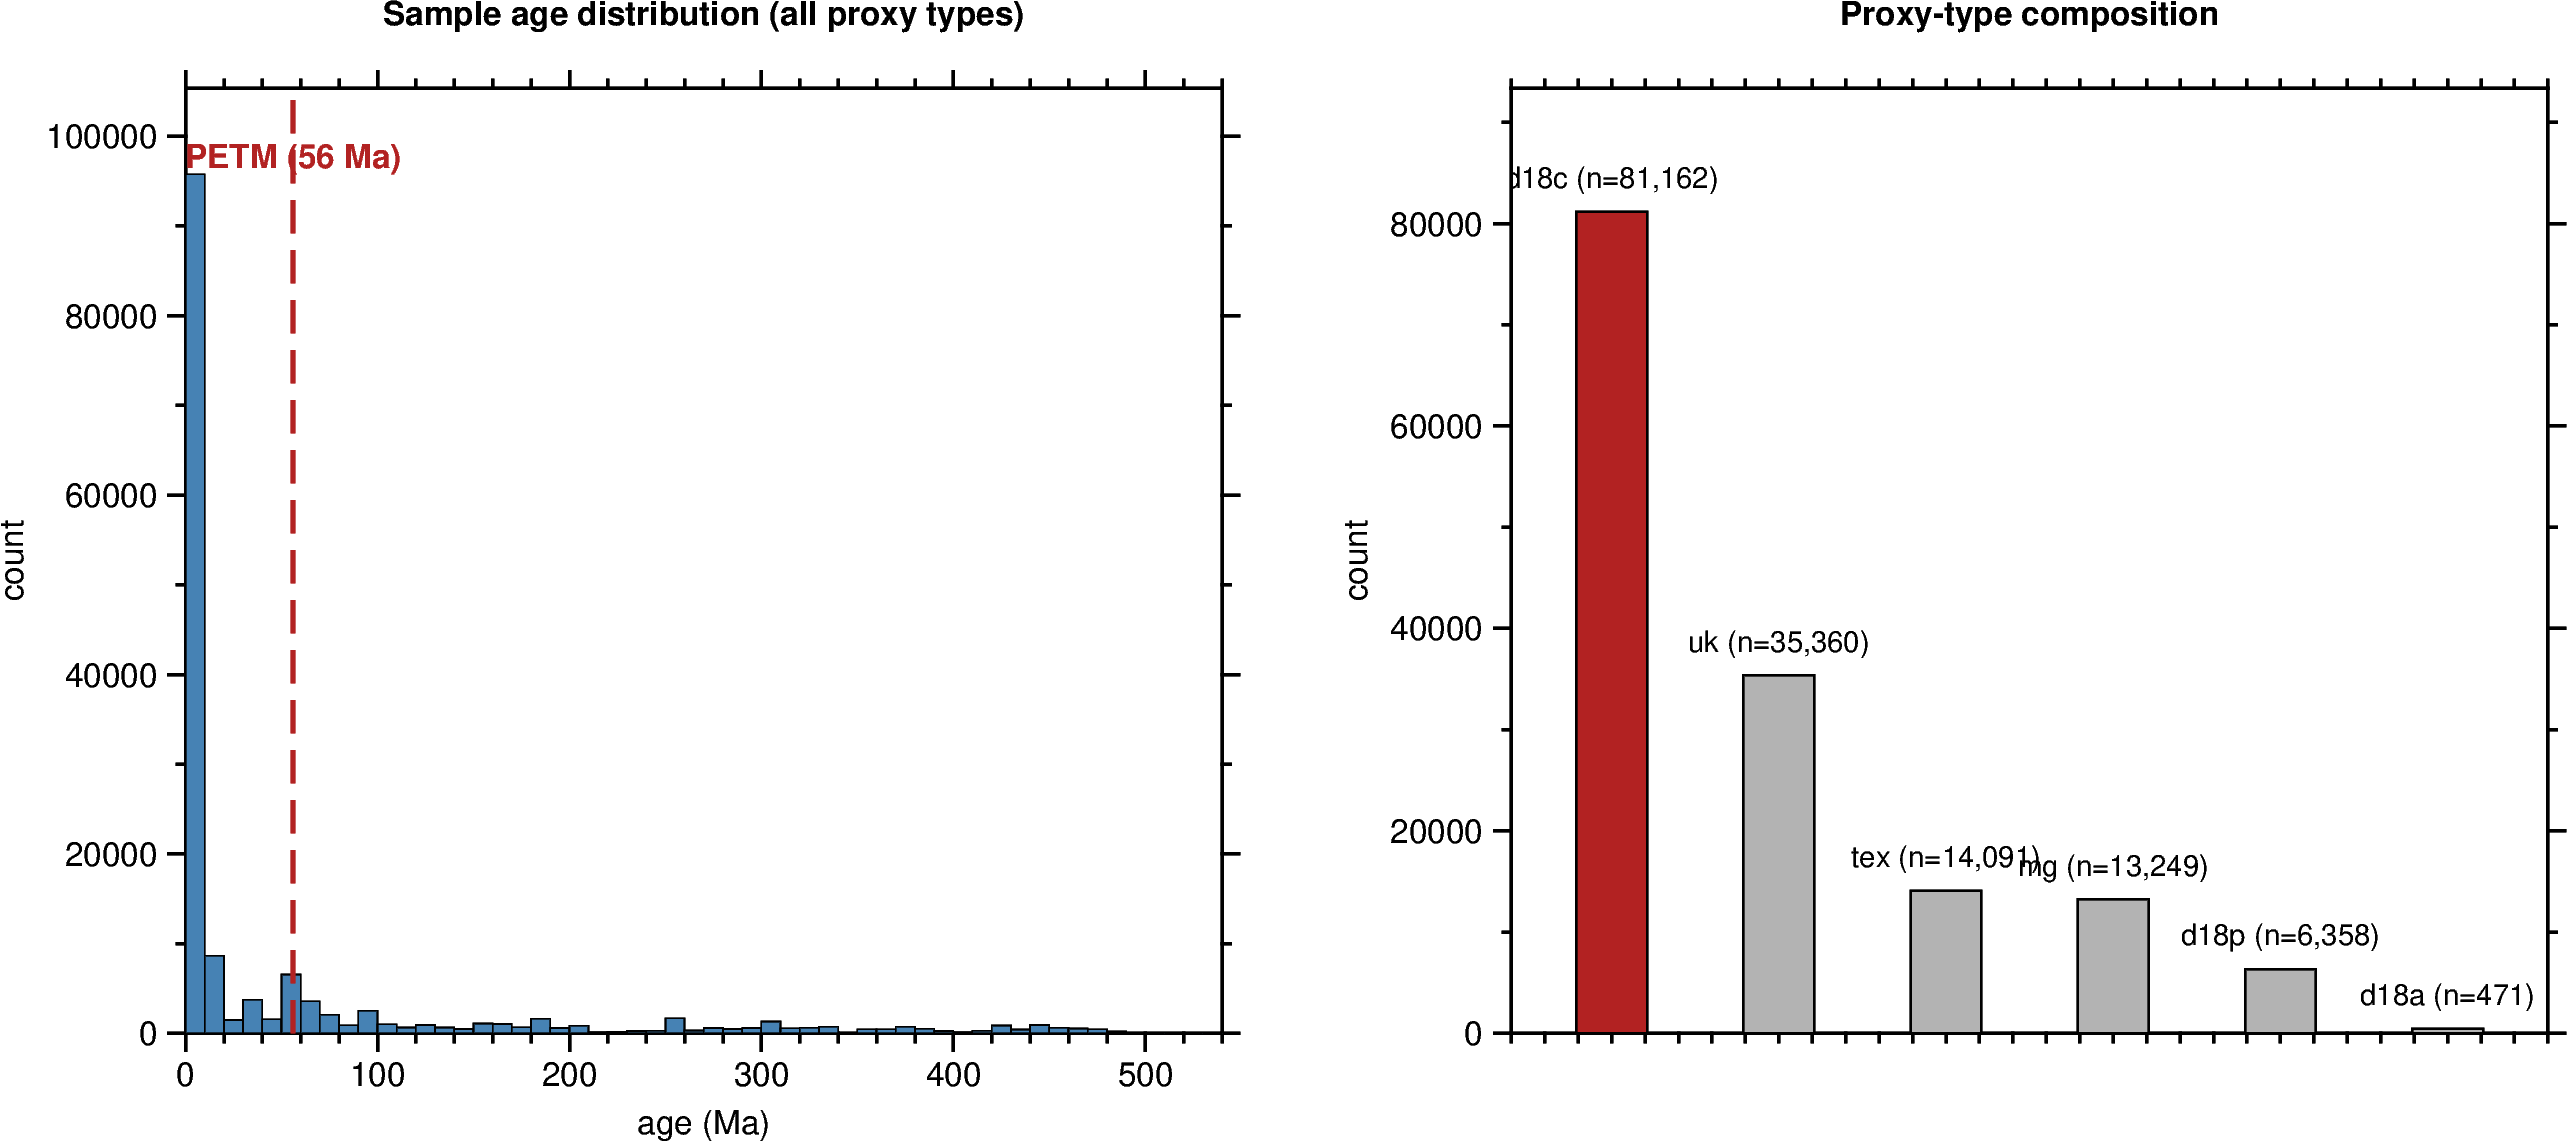

In [4]:
fig = pygmt.Figure()
with fig.subplot(nrows=1, ncols=2, figsize=("20c", "8c"), margins=["1c", "0.6c"]):
    # Panel 0: age histogram
    with fig.set_panel(panel=0):
        counts, edges = np.histogram(phansst["Age"].dropna(), bins=54, range=(0, 540))
        region = [0, 540, 0, counts.max() * 1.1]
        fig.basemap(region=region, projection="X?",
                    frame=["WSne+tSample age distribution (all proxy types)", "xaf+lage (Ma)", "yaf+lcount"])
        for i, c in enumerate(counts):
            fig.plot(x=[edges[i], edges[i+1], edges[i+1], edges[i]], y=[0, 0, c, c],
                      fill="steelblue", pen="0.3p,black", close=True)
        fig.plot(x=[56, 56], y=[0, counts.max() * 1.1], pen="1p,firebrick,-")
        fig.text(x=56, y=counts.max() * 1.05, text="PETM (56 Ma)", font="8p,Helvetica-Bold,firebrick",
                  justify="TC", offset="0/-0.1c")
    # Panel 1: proxy type composition
    with fig.set_panel(panel=1):
        vc = phansst["ProxyType"].value_counts()
        region = [-0.6, len(vc) - 0.4, 0, vc.max() * 1.15]
        fig.basemap(region=region, projection="X?",
                    frame=["WSne+tProxy-type composition", "xf", "yaf+lcount"])
        for i, (ptype, n) in enumerate(vc.items()):
            fill = "firebrick" if ptype == PROXY_TYPE else "gray70"
            fig.plot(x=[i], y=[n], style="b0.6c+b0", fill=fill, pen="0.5p,black")
            fig.text(x=i, y=n, text=f"{ptype}\n(n={n:,})", offset="0/0.2c", justify="BC", font="7p")
fig.savefig(OUTPUT_DIR / "T70_database_overview.png", dpi=150)
fig.show(width=1000)


**What this shows.** Sample density is very uneven across the Phanerozoic -- unsurprising, since it tracks where and when people have drilled and analysed cores, not a designed sampling scheme -- with pronounced peaks in the Cenozoic (dense ocean-drilling coverage) and comparatively sparse Paleozoic representation. &delta;<sup>18</sup>O carbonate (`d18c`) is by far the largest single proxy type in the database, which is why it is the one this notebook standardises on: mixing proxy types on one colour scale would conflate physically different measurements (a Mg/Ca ratio and a &delta;<sup>18</sup>O value are not the same unit, let alone the same sign convention).

## 3. Isolating one event: the Paleocene-Eocene Thermal Maximum (~56 Ma)

The PETM is the best-sampled hyperthermal event in PhanSST's &delta;<sup>18</sup>O carbonate record. Subsetting to a single proxy type inside a narrow age window keeps every plotted value physically comparable, at some cost in sample size relative to the full database.

In [5]:
petm = phansst[(phansst["Age"] >= TARGET_AGE - AGE_WINDOW) &
               (phansst["Age"] <= TARGET_AGE + AGE_WINDOW) &
               (phansst["ProxyType"] == PROXY_TYPE)].dropna(subset=["ModLat", "ModLon", "ProxyValue"]).copy()

# One row per unique site, ProxyValue averaged across any repeat measurements at
# the exact same coordinates -- keeps every later step (reconstruction, mapping,
# the latitude-gradient check) at one physically comparable value per site.
sites = (petm.groupby(["ModLat", "ModLon"], as_index=False)
         .agg(ProxyValue=("ProxyValue", "mean"), SiteName=("SiteName", "first"), n_meas=("ProxyValue", "size")))
print(f"  {len(petm)} {PROXY_TYPE} measurements, {len(sites)} unique sites, "
      f"in [{TARGET_AGE-AGE_WINDOW:.0f}, {TARGET_AGE+AGE_WINDOW:.0f}] Ma")
print(f"  {petm['SiteName'].nunique()} named sites; source studies: {petm['LeadAuthor'].nunique()}")
print(f"  present-day site locations span {sites['ModLat'].min():.1f} to {sites['ModLat'].max():.1f} deg latitude")


  3928 d18c measurements, 35 unique sites, in [54, 58] Ma
  36 named sites; source studies: 30
  present-day site locations span -65.2 to 49.1 deg latitude


## 4. Reconstructing site positions to 56 Ma

**First attempt -- `gplately`'s default static-polygon reconstruction.** This is the pattern used elsewhere in this suite for reconstructing point data (see T61, T71): assign each point a plate ID from the model's continent-only static polygons, then rotate.

In [6]:
pmm = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="data/pmm_cache")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
)

pts = gplately.Points(recon, sites["ModLon"].values, sites["ModLat"].values)
rlon_static, rlat_static, kept_idx_static = pts.reconstruct(TARGET_AGE, return_array=True, return_point_indices=True)
print(f"  static continental polygons: {len(kept_idx_static)}/{len(sites)} sites reconstructed "
      f"({len(sites) - len(kept_idx_static)} dropped)")


  static continental polygons: 13/35 sites reconstructed (22 dropped)


**Most sites are dropped.** `scotese_and_wright2018`'s static polygons cover continental crust only (no oceanic-plate polygons -- the same limitation noted in earlier notebooks in this suite). SST proxy records are disproportionately drawn from open-ocean DSDP/ODP/IODP drill cores sitting on abyssal ocean floor, so this is close to a worst case for that limitation, not a rare edge case.

**Fix: partition through the model's own topological plate boundaries instead of its static polygons.** A plate model's resolved topological boundaries tile the *entire* globe, ocean basins included (that is what makes them usable to build plate velocity fields everywhere) -- so partitioning through them, rather than through the continent-only static polygons, assigns every point a plate ID regardless of whether it sits on land or open ocean.

In [7]:
rotation_model = pygplates.RotationModel(model.get_rotation_model())
topologies = model.get_topologies()

resolved_topologies = []
pygplates.resolve_topologies(topologies, rotation_model, resolved_topologies, 0.0)
partitioner = pygplates.PlatePartitioner(resolved_topologies, rotation_model)

plate_ids = []
for lon, lat in zip(sites["ModLon"], sites["ModLat"]):
    partition = partitioner.partition_point(pygplates.PointOnSphere(lat, lon))
    plate_ids.append(partition.get_feature().get_reconstruction_plate_id() if partition is not None else np.nan)
sites["plate_id"] = plate_ids

n_assigned = sites["plate_id"].notna().sum()
print(f"  topological partitioning: {n_assigned}/{len(sites)} sites assigned a plate ID")

sites = sites.dropna(subset=["plate_id"]).copy()
paleo_lat, paleo_lon = [], []
for _, row in sites.iterrows():
    rotation = rotation_model.get_rotation(TARGET_AGE, int(row["plate_id"]), 0.0)
    rotated_point = rotation * pygplates.PointOnSphere(row["ModLat"], row["ModLon"])
    lat, lon = rotated_point.to_lat_lon()
    paleo_lat.append(lat); paleo_lon.append(lon)
sites["paleo_lat"] = paleo_lat
sites["paleo_lon"] = paleo_lon
print(f"  all {len(sites)} sites successfully reconstructed to {TARGET_AGE:.0f} Ma")


  topological partitioning: 35/35 sites assigned a plate ID
  all 35 sites successfully reconstructed to 56 Ma


**What this shows.** Going from static-polygon partitioning to topological partitioning recovers every site, because the failure mode was never about the *rotation* (the plate model has always been able to rotate any point once it knows which plate the point is on) -- it was about *plate-ID assignment* for locations the continent-only static polygons simply do not cover. This is a general fix, not a PhanSST-specific one: any point dataset with open-ocean locations (proxy sites, drill cores, seafloor samples) will hit the same static-polygon gap in any plate model whose static polygons are continent-only.

## 5. Mapping the reconstructed sites

&delta;<sup>18</sup>O carbonate values at their real 56 Ma positions, with the model's own resolved plate boundaries drawn for tectonic context. Carbonate &delta;<sup>18</sup>O is an inverse temperature proxy -- more negative values generally indicate warmer conditions -- so the colour scale is reversed relative to a typical "high value = hot" convention.

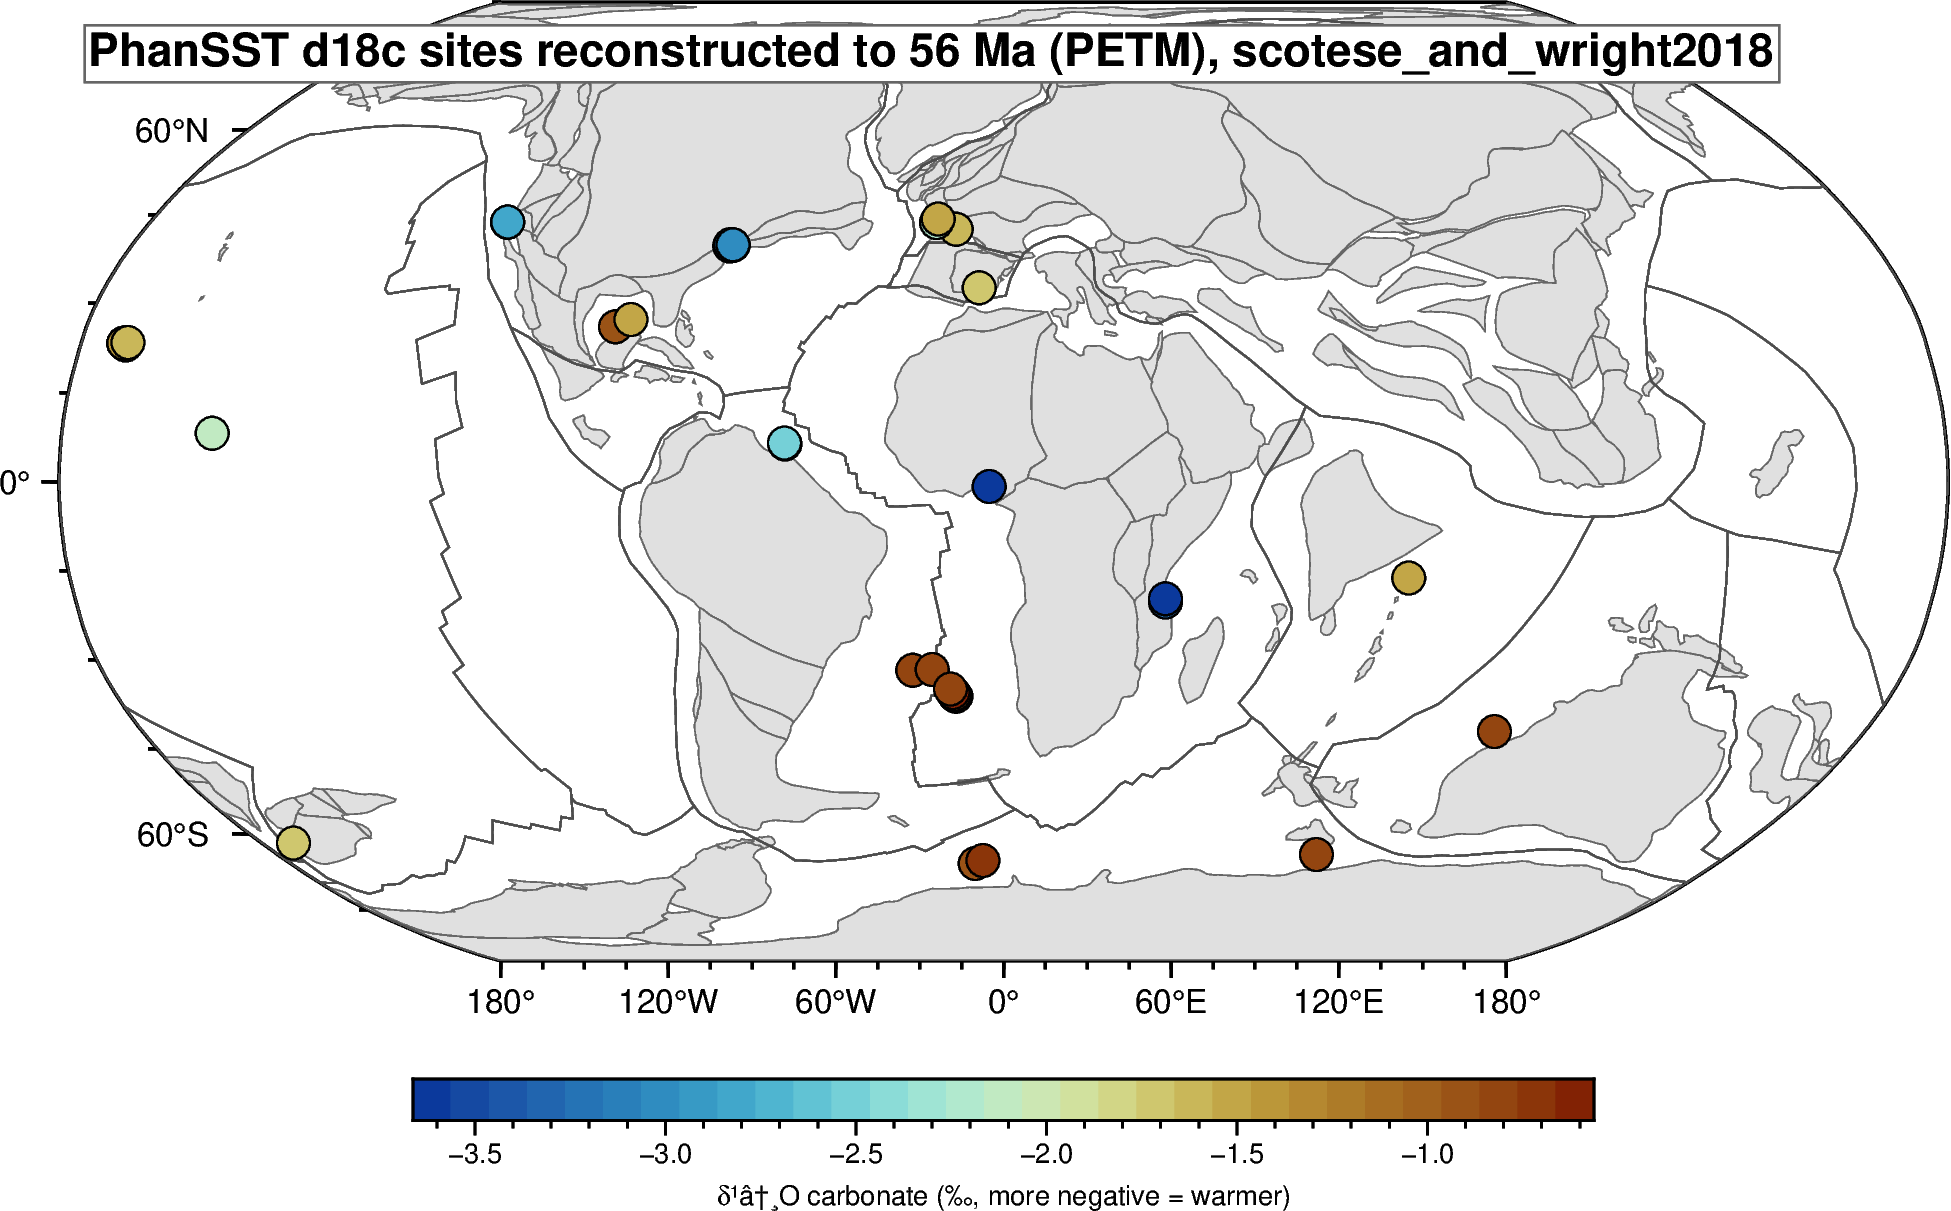

In [8]:
gm = gplately.PlotTopologies(
    plate_reconstruction=recon,
    continents=model.get_continental_polygons(),
    COBs=model.get_COBs(),
    time=float(TARGET_AGE),
    plot_engine=gplately.PygmtPlotEngine(),
)

merged = sites  # already one averaged ProxyValue per unique reconstructed site (see SS3)

fig = pygmt.Figure()
pygmt.makecpt(cmap="roma", series=[merged["ProxyValue"].min(), merged["ProxyValue"].max(), 0.1],
              reverse=True, background="o")
fig.basemap(region=REGION, projection=PROJ, frame="af")
gm.plot_continents(fig, fill="gray88", pen="0.3p,gray40")
gm.plot_all_topologies(fig, color="gray30", pen="0.4p,gray30")
fig.plot(x=merged["paleo_lon"], y=merged["paleo_lat"], style="c0.28c", fill=merged["ProxyValue"],
          cmap=True, pen="0.4p,black")
fig.colorbar(frame="af+l\u03b4\u00b9\u2078O carbonate (\u2030, more negative = warmer)",
              position="JBC+w10c/0.35c+h+o0/1c")
fig.text(text=f"PhanSST {PROXY_TYPE} sites reconstructed to {TARGET_AGE:.0f} Ma (PETM), {MODEL_NAME}",
          position="TL", offset="0.25c/-0.25c", justify="TL",
          font="11p,Helvetica-Bold,black", fill="white", pen="0.5p,gray40")
fig.savefig(OUTPUT_DIR / "T70_petm_map.png", dpi=150)
fig.show(width=800)


**What this shows.** The 35 reconstructed PETM sites cluster in the mid-latitude North Atlantic margin (a dense DSDP/ODP drilling target) and the South Atlantic, with a handful of Pacific and low-latitude sites, on the Eocene ocean basin geometry -- a still-narrow North Atlantic and a wide Tethys/proto-Mediterranean gap between Africa and Eurasia. Grey lines show the model's own reconstructed plate boundaries at 56 Ma: several sites sit close to the young Mid-Atlantic Ridge, consistent with their present-day locations on North Atlantic margin crust that was, in the Eocene, much nearer the spreading centre that created it.

## 6. Does the data show the latitudinal gradient it should?

A basic, falsifiable check: if &delta;<sup>18</sup>O carbonate tracks temperature and temperature falls with latitude, reconstructed |paleolatitude| and &delta;<sup>18</sup>O should be **positively** correlated (warmer/more-negative values near the paleo-equator, cooler/less-negative values toward the paleo-poles). This uses the *reconstructed* paleolatitude, not present-day latitude -- several sites have moved enough since 56 Ma (see &sect;5) that the two are not interchangeable for this test.

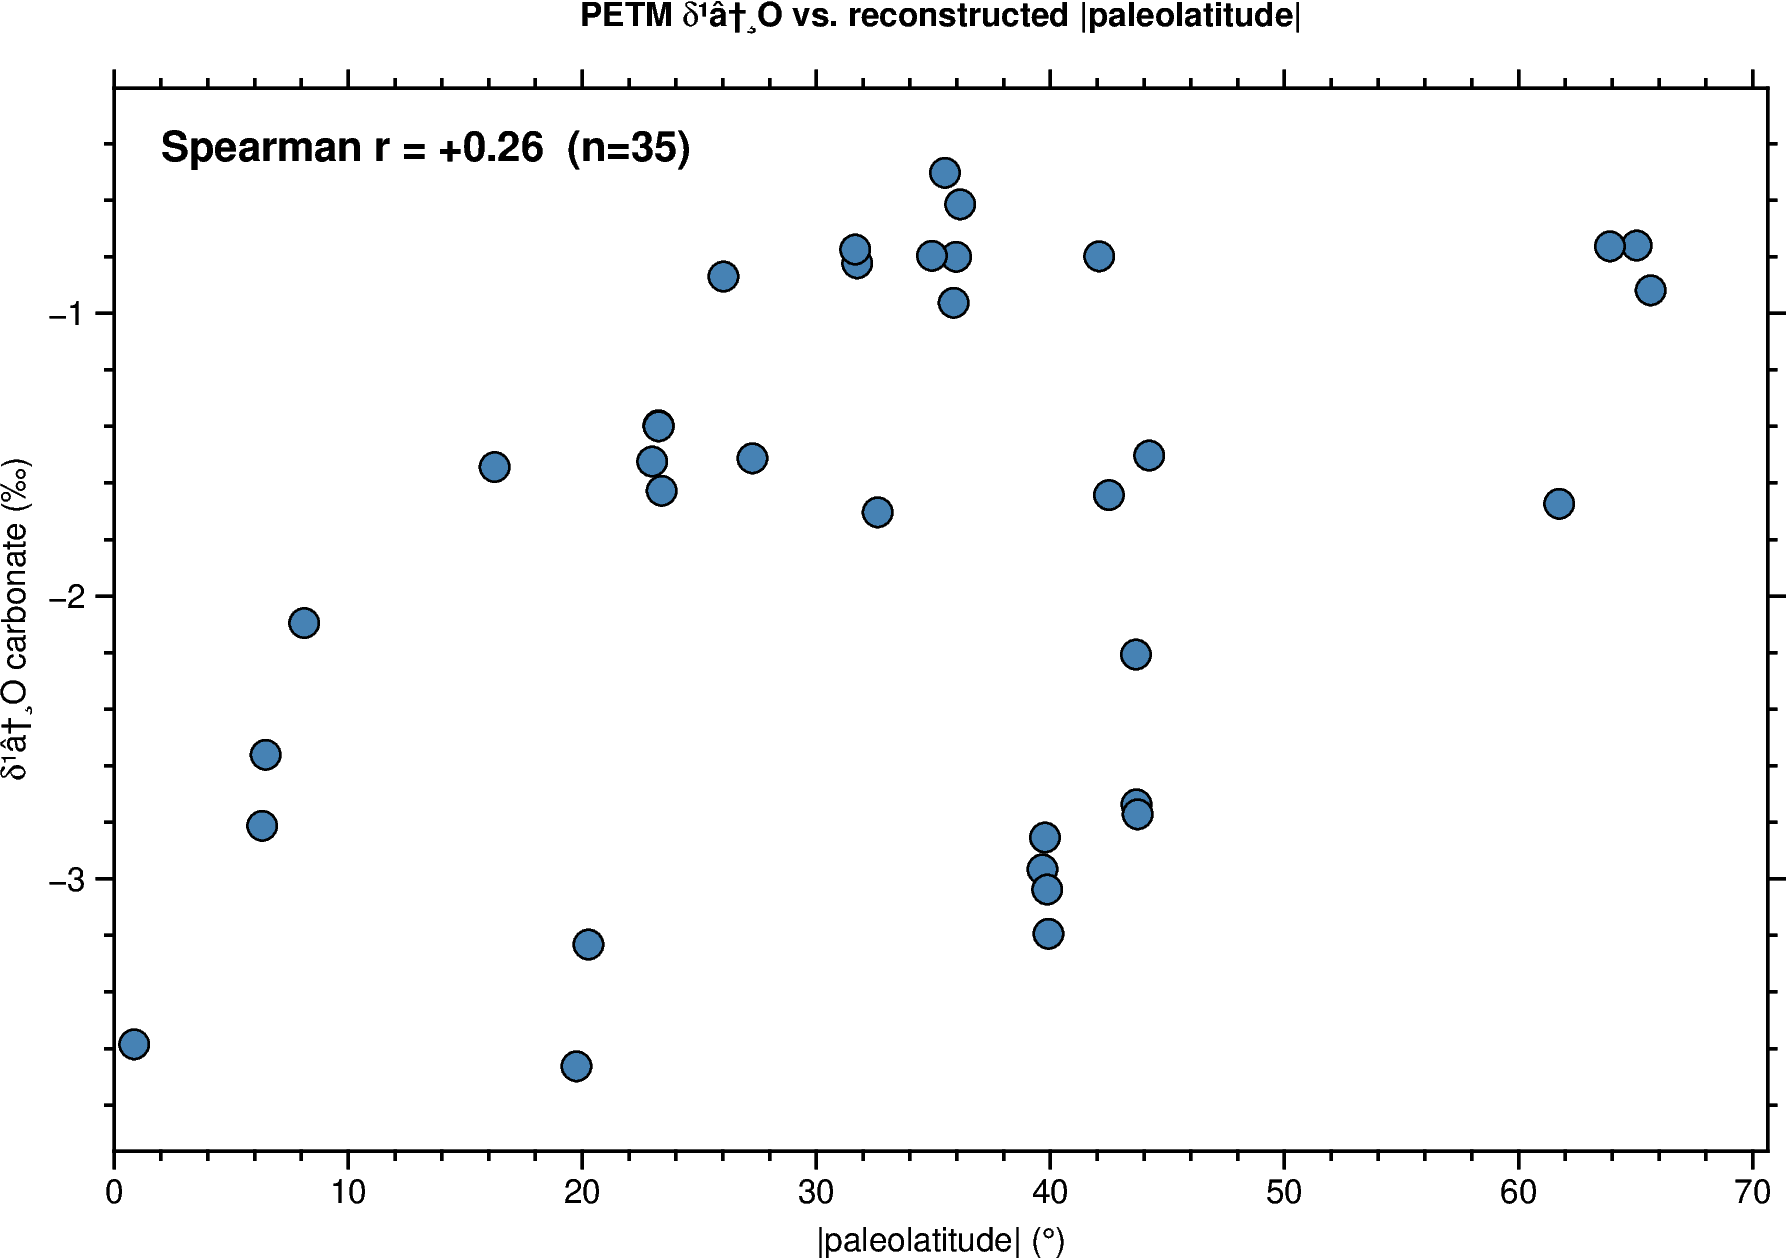

  Spearman rank correlation (|paleolatitude| vs. delta-18-O): +0.26, n=35


In [9]:
merged["abs_paleolat"] = merged["paleo_lat"].abs()
rank_lat = merged["abs_paleolat"].rank()
rank_val = merged["ProxyValue"].rank()
spearman = np.corrcoef(rank_lat, rank_val)[0, 1]

fig = pygmt.Figure()
region = [0, merged["abs_paleolat"].max() + 5, merged["ProxyValue"].min() - 0.3, merged["ProxyValue"].max() + 0.3]
fig.basemap(region=region, projection="X14c/9c",
            frame=["WSne+tPETM \u03b4\u00b9\u2078O vs. reconstructed |paleolatitude|",
                   "xaf+l|paleolatitude| (\u00b0)", "yaf+l\u03b4\u00b9\u2078O carbonate (\u2030)"])
fig.plot(x=merged["abs_paleolat"], y=merged["ProxyValue"], style="c0.25c", fill="steelblue", pen="0.5p,black")
fig.text(x=region[0] + 2, y=region[3] - 0.15, text=f"Spearman r = {spearman:+.2f}  (n={len(merged)})",
          justify="TL", font="10p,Helvetica-Bold")
fig.savefig(OUTPUT_DIR / "T70_petm_latitude_gradient.png", dpi=150)
fig.show(width=750)
print(f"  Spearman rank correlation (|paleolatitude| vs. delta-18-O): {spearman:+.2f}, n={len(merged)}")


**What this shows.** The correlation is positive, in the direction the latitudinal-temperature-gradient hypothesis predicts (less-negative, cooler-reading &delta;<sup>18</sup>O toward higher paleolatitude) -- but with only 35 points spread across a limited latitude range and multiple confounds this reconstruction cannot control for (water depth, local salinity, diagenetic alteration, inter-laboratory calibration differences), this is a directionally-consistent signal, not a rigorous test of the PETM's temperature gradient. Judd et al. (2022) and follow-on work built on PhanSST (e.g. the companion PhanDA data-assimilation product) apply proxy-specific calibration equations and much larger, better-controlled subsets to do that properly; this notebook stops at the reconstruction-and-sanity-check stage that makes such an analysis possible in the first place.

## Extend this

- **Try a different event or proxy type.** Swap `TARGET_AGE`/`AGE_WINDOW`/`PROXY_TYPE` for another well-sampled interval -- the Cretaceous (66-145 Ma) has over 11,000 rows in this database, mostly `d18c` as well, and would let you compare a hothouse-greenhouse gradient against this icehouse-adjacent PETM one.
- **Apply a real paleotemperature calibration.** This notebook stops at raw &delta;<sup>18</sup>O values (see &sect;6's caveats). Converting to actual temperature requires a proxy-specific calibration equation and an assumption about contemporaneous seawater &delta;<sup>18</sup>O -- worth doing explicitly rather than implicitly.
- **Compare proxy types at the same sites.** A handful of PETM sites in this window have both `d18c` and `mg` (Mg/Ca) measurements -- an internal cross-proxy consistency check, independent of the plate reconstruction.
- **Push the topological-partitioning fix further back in time.** This notebook demonstrates it at a single age (56 Ma); the same static-polygon gap will reappear at any other age for any other continent-only plate model, including several other Cluster J notebooks in this suite.

## Related notebooks

- **T61** -- Paleo-bioregionalisation via H3 + hierarchical clustering. Another point-reconstruction workflow using this suite's default static-polygon pattern.
- **T64** -- Deep-time paleoclimate snapshots. Complementary paleoclimate-proxy rendering, different data source.
- **T68** -- Reference-frame paleoclimate. Explores how reconstruction choices change a paleoclimate map, the same theme this notebook applies to point data specifically.

## References

Judd, E.J., Tierney, J.E., Lunt, D.J., Montanez, I.P., Huber, B.T., Wing, S.L. & Valdes, P.J. (2022). The PhanSST global database of Phanerozoic sea surface temperature proxy data. *Scientific Data* 9, 753. https://doi.org/10.1038/s41597-022-01826-0 (CC BY 4.0). Data archive: https://doi.org/10.5281/zenodo.7049233

Scotese, C.R. & Wright, N. (2018). PALEOMAP Paleodigital Elevation Models (PaleoDEMS) for the Phanerozoic. https://www.earthbyte.org/paleodem-resource-scotese-and-wright-2018/

Mather, B.R., Muller, R.D., Zahirovic, S., et al. (2024). Deep time spatio-temporal data analysis using GPlately. *Geoscience Data Journal* 11, 3-10. https://doi.org/10.1002/gdj3.185
